In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Load the graph
import networkx as nx
G = nx.read_gml('../data/graph/LEMD_EGLL_2023_04_01.gml')
# Load node ID mappings
node_list = list(G.nodes())
node_to_idx = {node: idx for idx, node in enumerate(node_list)}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

In [3]:
# Shortest path from LEMD to EGLL
shortest_path = nx.shortest_path(G, source='LEMD', target='EGLL')
print(shortest_path)

['LEMD', 'LETP', 'KOVAK', 'EGLL']


In [4]:
import numpy as np
# Load the backward value functions
V_final_bw = np.load('../data/results/backward/V_final_bw.npy')
eta_final_bw = np.load('../data/results/backward/eta_final_bw.npy')
alt_final_bw = np.load('../data/results/backward/alt_final_bw.npy')
phase_final_bw = np.load('../data/results/backward/phase_final_bw.npy')
V_final_margin_bw = np.array([np.sum(row[np.isfinite(row)]) for row in V_final_bw])

# Inspection

In [5]:
V_final_bw[node_to_idx['EGLL']]

array([inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf,  0.])

In [6]:
print('V_final_bw[LEMD]')
print(V_final_bw[node_to_idx['LEMD']])
print('eta_final_bw[LEMD]')
print(eta_final_bw[node_to_idx['LEMD']])
eta_final_at_source = eta_final_bw[node_to_idx['LEMD']]
eta_final_at_goal = eta_final_bw[node_to_idx['EGLL']]
# Replace nan with -inf in eta_final_at_source
eta_final_at_source_no_nan = np.where(np.isnan(eta_final_at_source), -np.inf, eta_final_at_source)
eta_final_at_goal_no_nan = np.where(np.isnan(eta_final_at_goal), -np.inf, eta_final_at_goal)

V_final_bw[LEMD]
[-0.33961412 -0.34160773 -0.33970046 -0.34569108 -0.34508636 -0.34473485
 -0.34657896 -0.34481881 -0.3404499  -0.34367971 -0.33912242 -0.34310857
 -0.33364881 -0.3353713  -0.33934818 -0.3278813  -0.32462129 -0.32077369
 -0.31877074 -0.30547547 -0.28557879 -0.21985605         inf         inf
         inf         inf         inf         inf         inf         inf
         inf]
eta_final_bw[LEMD]
[25429.56815204 25578.09506505 26599.99069809 27187.98979893
 27776.47086804 27943.54465212 28810.19072528 29438.86519038
 29915.03417535 30515.4415169  30927.49289834 31616.12374189
 32209.2939561  33025.58443452 33515.99956165 34215.67276597
 34955.33268135 35649.12186663 36117.70758928 36728.73127363
 37010.6432424  37524.75556824            nan            nan
            nan            nan            nan            nan
            nan            nan            nan]


In [7]:
from equinox.helpers.datetimeh import seconds_since_midnight_to_datestr
takeoff_ssm = np.nanmax(eta_final_bw[node_to_idx['LEMD']])
print(f'Takeoff SSM: {takeoff_ssm}')
takeoff_str = seconds_since_midnight_to_datestr("2023-04-01", takeoff_ssm)
print(f'Take off at LEMD: {takeoff_str}')
print(f'Time bin at takeoff should be: {np.argmax(eta_final_at_source_no_nan)}')

landing_ssm = np.nanmin(eta_final_bw[node_to_idx['EGLL']])
landing_str = seconds_since_midnight_to_datestr("2023-04-01", landing_ssm)
print(f'Landing at EGLL: {landing_str}')
print(f'Time bin at landing should be: {np.argmax(eta_final_at_goal_no_nan)}')


Takeoff SSM: 37524.755568242304
Take off at LEMD: 2023-04-01 10:25:24
Time bin at takeoff should be: 21
Landing at EGLL: 2023-04-01 12:00:00
Time bin at landing should be: 30


In [8]:
# Load the distance matrix
dist_matrix = np.load('../data/graph/LEMD_EGLL_2023_04_01_distances.npy')

# Load the airspace charges matrix
ac_matrix = np.load('../data/graph/LEMD_EGLL_2023_04_01_charges.npy')

node_to_idx = {node_id: i for i, node_id in enumerate(G.nodes())}

# Sample a Route

In [40]:
import importlib
import equinox.sampling.sample_route
importlib.reload(equinox.sampling.sample_route)
from equinox.sampling.sample_route import sample_routes
from equinox.sampling.sample_route import sample_routes
from equinox.cost.cost_model_1 import cost_model_1
from equinox.wind.wind_date import WindDate
import torch 
from equinox.vnav.vnav_performance import Performance, get_eta_and_distance_climb
from equinox.vnav.vnav_profiles_rev1 import NARROW_BODY_JET_CLIMB_PROFILE, NARROW_BODY_JET_DESCENT_PROFILE, NARROW_BODY_JET_CLIMB_VS_PROFILE, NARROW_BODY_JET_DESCENT_VS_PROFILE
narrow_body_jet_performance = Performance(
    climb_speed_profile=NARROW_BODY_JET_CLIMB_PROFILE,
    descent_speed_profile=NARROW_BODY_JET_DESCENT_PROFILE,
    climb_vertical_speed_profile=NARROW_BODY_JET_CLIMB_VS_PROFILE,
    descent_vertical_speed_profile=NARROW_BODY_JET_DESCENT_VS_PROFILE,
    cruise_altitude_ft=35000.0,
    cruise_speed_kts=450.0
)

climb_perf_table = get_eta_and_distance_climb(
    narrow_body_jet_performance,
    origin_airport_elevation_ft=0
)

wind_model = WindDate(date_str="2024-04-01", data_dir='../data/era5')

device = torch.device("cpu")

import importlib
importlib.reload(equinox.sampling.sample_route)


routes, leg_dists = sample_routes(
    graph=G,
    landing_time_str="2023-04-01 12:00:00", # must be same as in the backward DP process
    max_flight_duration_hours=5, # must be same as in the backward DP process
    takeoff_time_str=takeoff_str, # must be from the latest take-off time from the backward DP values (see above)
    dist_matrix_np=dist_matrix,
    ac_matrix_np=ac_matrix,
    wind_model=wind_model,
    V_bwd = torch.tensor(V_final_bw, dtype=torch.float64, device=device),
    source_node_id='LEMD',
    goal_node_id='EGLL',
    cost_model=cost_model_1,
    performance_model=narrow_body_jet_performance,
    source_elevation_ft=0,
    initial_alt_ft_amsl=0,
    delta_t_seconds=600, # must be same as in the backward DP process
    device_str="cpu",
    num_samples=100,
    temperature=1,
    verbose=False
)

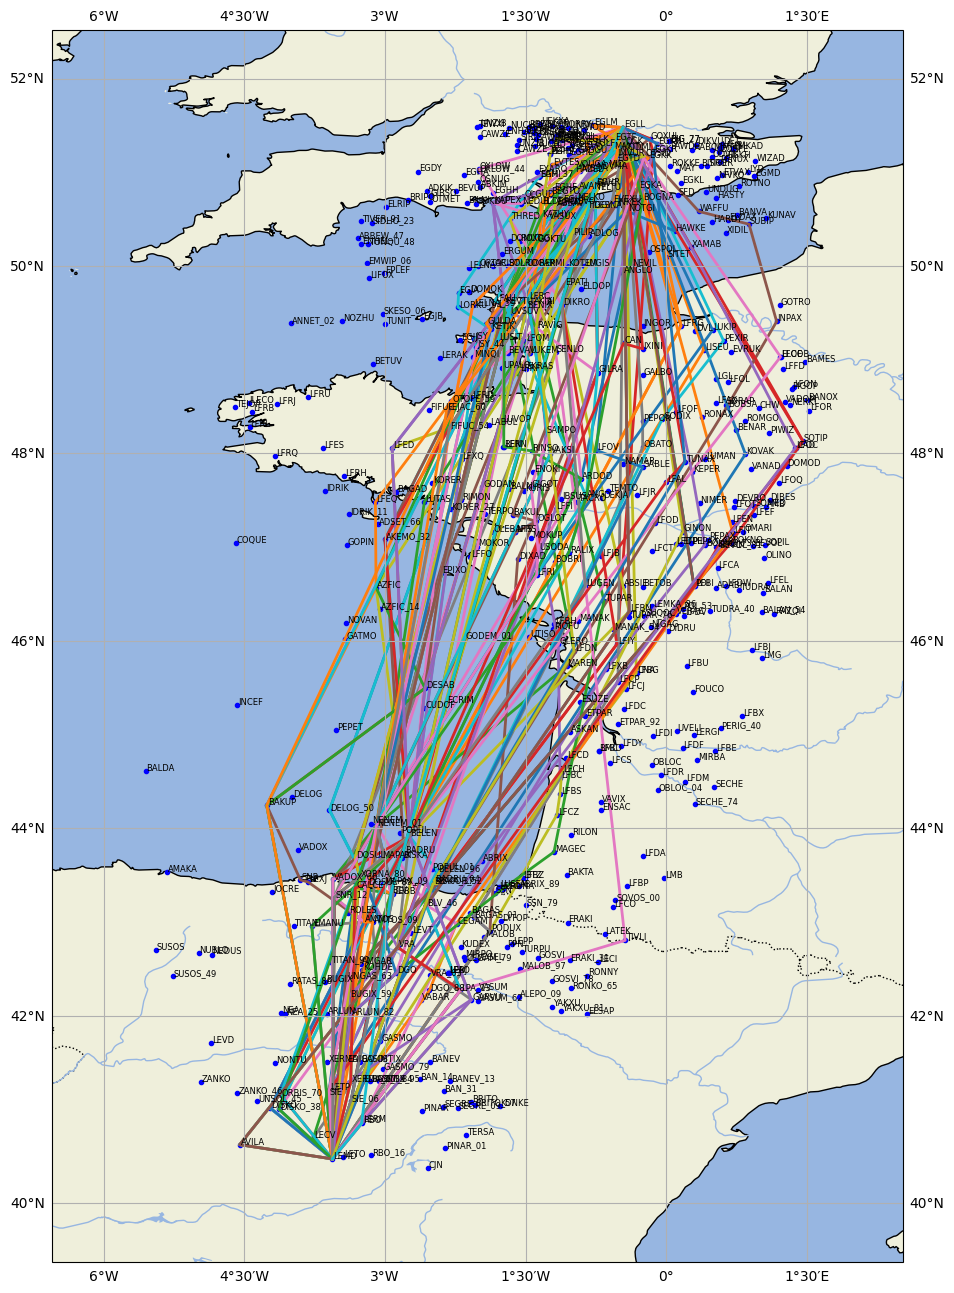

In [41]:
from equinox.helpers.plotters import plot_routes_on_map

plot_routes_on_map(G, routes)


In [42]:
route_total_distances = np.array([np.sum(np.array(x)) for x in leg_dists])
for route, leg_dist in zip(routes, leg_dists):
    print(f'Route: {route}, Leg Distance: {np.sum(np.array(leg_dist)):.2f}')


Route: ['LEMD', 'SIE_06', 'BLV', 'DOSUL_89', 'BELEN', 'ARDOD', 'BOGNA', 'EGLL'], Leg Distance: 690.50
Route: ['LEMD', 'CALCE', 'XORNA_80', 'BELEN', 'LISEU', 'EGLL'], Leg Distance: 699.86
Route: ['LEMD', 'VADOX_66', 'NENEM_01', 'MAREN', 'LFDN', 'REVTU', 'ELDER', 'EGHN', 'EGHF', 'NIBDA', 'EGLL'], Leg Distance: 717.84
Route: ['LEMD', 'UNGAS_63', 'BAPOR_52', 'BOKNO', 'SOTIP', 'OCK', 'EGLL'], Leg Distance: 732.54
Route: ['LEMD', 'PODUX', 'BAGAS_01', 'LFBC', 'OLERO', 'OGLOT', 'SAMPO', 'RAVIG', 'LFAU', 'VASUX', 'GWC', 'EGHR', 'EGLL'], Leg Distance: 711.88
Route: ['LEMD', 'XORNA_80', 'DOSUL', 'RIMON', 'LFAU', 'VASUX', 'GOXUL', 'EGLL'], Leg Distance: 691.45
Route: ['LEMD', 'SNR_12', 'XORNA_80', 'NENEM_01', 'LELNA_59', 'NELKO', 'NOVMA', 'EGTF', 'EGLL'], Leg Distance: 684.84
Route: ['LEMD', 'UNGAS_63', 'REVTU', 'INKEK', 'OCK', 'EGLL'], Leg Distance: 681.65
Route: ['LEMD', 'PODUX', 'LFCZ', 'LFBS', 'LFCH', 'LFBG', 'OCK', 'EGLL'], Leg Distance: 693.82
Route: ['LEMD', 'DISKO', 'AMTOS', 'NENEM_01', 'J

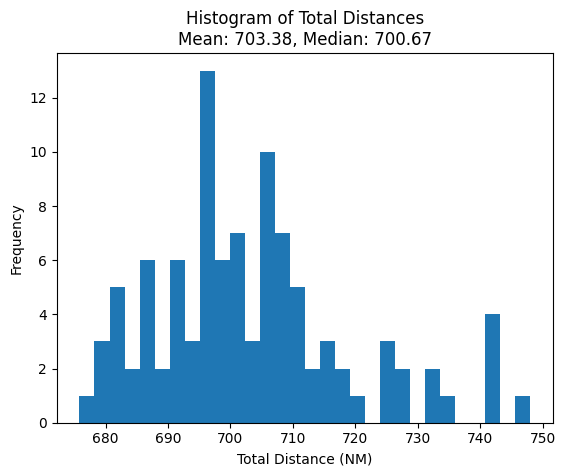

In [47]:
from matplotlib import pyplot as plt
plt.hist(route_total_distances, bins=30)
plt.xlabel('Total Distance (NM)')
plt.ylabel('Frequency')
plt.title(f'Histogram of Total Distances\nMean: {np.mean(route_total_distances):.2f}, Median: {np.median(route_total_distances):.2f}')
plt.show()